# Elasticidade linear

Agora a incógnita deixa de ser escalar: queremos o deslocamento
$u : \Omega \to \mathbb{R}^2$ em pequenas deformações.

No regime linear isotrópico, o modelo é

$$
\begin{cases}
-\nabla \cdot \sigma(u) = f & \text{em } \Omega, \\
u = \bar{u} & \text{em } \Gamma_D, \\
\sigma(u)n = \bar{t} & \text{em } \Gamma_N,
\end{cases}
$$

com

$$
\varepsilon(u) = \frac{1}{2}\left(\nabla u + \nabla u^T\right),
\qquad
\sigma(u) = \lambda \, \mathrm{tr}(\varepsilon(u)) I + 2\mu \, \varepsilon(u).
$$

## Forma fraca

Tomando uma função-teste vetorial $v \in [H_0^1(\Omega)]^2$, multiplicamos a
equação por $v$ e integramos sobre o domínio:

$$
\int_\Omega (-\nabla \cdot \sigma(u)) \cdot v \, dx
=
\int_\Omega f \cdot v \, dx.
$$

Após integração por partes,

$$
\int_\Omega \sigma(u) : \varepsilon(v) \, dx
=
\int_\Omega f \cdot v \, dx + \int_{\Gamma_N} \bar{t} \cdot v \, ds.
$$

Neste notebook, vamos considerar apenas força de corpo e uma extremidade
engastada, de modo que o termo de tração na fronteira não aparece
explicitamente.

## Configuração do problema

Usaremos uma barra retangular $\Omega = [0, L_x] \times [0, L_y]$, engastada
na face esquerda e sujeita a uma carga de corpo vertical. A ideia é produzir
um campo de deslocamentos visualmente claro, sem complicar o modelo com muitos
detalhes geométricos.

In [1]:
import os

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")

from mpi4py import rc

rc.finalize = False

from mpi4py import MPI
from petsc4py import PETSc

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
import ufl
from dolfinx import fem, mesh, plot
from dolfinx.fem import petsc

In [2]:
Lx, Ly = 1.0, 0.2
domain = mesh.create_rectangle(
    MPI.COMM_WORLD,
    [np.array([0.0, 0.0]), np.array([Lx, Ly])],
    [36, 8],
    cell_type=mesh.CellType.triangle,
)
V = fem.functionspace(domain, ("Lagrange", 1, (domain.geometry.dim,)))

u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)

## Parâmetros constitutivos

Para dar significado físico mais imediato, partimos do módulo de Young $E$ e
do coeficiente de Poisson $\nu$, e então obtemos os parâmetros de Lamé:

$$
\mu = \frac{E}{2(1 + \nu)},
\qquad
\lambda = \frac{E \nu}{(1 + \nu)(1 - 2\nu)}.
$$

A interpretação aqui é de elasticidade linear isotrópica em pequenas
deformações; não estamos distinguindo explicitamente entre estado plano de
tensões e de deformações neste exemplo introdutório.

In [3]:
E = 12.0
nu = 0.30
mu_value = E / (2.0 * (1.0 + nu))
lambda_value = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))

mu = fem.Constant(domain, mu_value)
lambda_ = fem.Constant(domain, lambda_value)
rho = fem.Constant(domain, 0.08)
g = fem.Constant(domain, 9.81)
f = ufl.as_vector((0.0, -rho * g))
I = ufl.Identity(domain.geometry.dim)


def epsilon(w):
    return ufl.sym(ufl.grad(w))


def sigma(w):
    return lambda_ * ufl.tr(epsilon(w)) * I + 2.0 * mu * epsilon(w)


a = ufl.inner(sigma(u), epsilon(v)) * ufl.dx
L = ufl.dot(f, v) * ufl.dx

## Condição de contorno essencial

Engastamos a face esquerda, isto é, impomos deslocamento nulo em $x = 0$.

In [4]:
def clamped_left(x):
    return np.isclose(x[0], 0.0)


zero = np.array((0.0, 0.0), dtype=PETSc.ScalarType)
bc = fem.dirichletbc(zero, fem.locate_dofs_geometrical(V, clamped_left), V)

## Solução do problema variacional

In [5]:
problem = petsc.LinearProblem(
    a,
    L,
    bcs=[bc],
    petsc_options_prefix="elasticity_",
    petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
)
u_h = problem.solve()
u_h.name = "deslocamento"

## Quantidades derivadas

Vamos extrair as componentes do deslocamento, a norma nodal $|u_h|$ e uma
energia elástica simples

$$
\mathcal{E}_h = \frac{1}{2}\int_\Omega \sigma(u_h) : \varepsilon(u_h)\,dx.
$$

In [6]:
u_x = u_h.sub(0).collapse()
u_y = u_h.sub(1).collapse()

coords = u_x.function_space.tabulate_dof_coordinates()[:, :2]
ux_values = u_x.x.array.real
uy_values = u_y.x.array.real
umag_values = np.sqrt(ux_values**2 + uy_values**2)

strain_energy = 0.5 * fem.assemble_scalar(
    fem.form(ufl.inner(sigma(u_h), epsilon(u_h)) * ufl.dx)
)

print(f"u_x em [{ux_values.min():.6e}, {ux_values.max():.6e}]")
print(f"u_y em [{uy_values.min():.6e}, {uy_values.max():.6e}]")
print(f"|u| máximo: {umag_values.max():.6e}")
print(f"Energia elástica: {strain_energy:.6e}")

u_x em [-2.782495e-01, 2.770446e-01]
u_y em [-2.169317e+00, 0.000000e+00]
|u| máximo: 2.187034e+00
Energia elástica: 6.988877e-02


## Preparando triangulações para os gráficos

Para os campos escalares associados ao deslocamento, usamos a malha do espaço
escalar colapsado. Para a malha deformada, deslocamos os vértices de acordo
com um fator de amplificação puramente visual.

In [7]:
topology, _, geometry = plot.vtk_mesh(u_x.function_space)
triangles = topology.reshape((-1, 4))[:, 1:]
triangulation = mtri.Triangulation(geometry[:, 0], geometry[:, 1], triangles)

scale = 0.18 / max(umag_values.max(), 1e-14)
deformed_triangulation = mtri.Triangulation(
    geometry[:, 0] + scale * ux_values,
    geometry[:, 1] + scale * uy_values,
    triangles,
)


def make_levels(values, nlevels=25):
    vmin = float(values.min())
    vmax = float(values.max())
    if np.isclose(vmin, vmax):
        vmax = vmin + 1.0
    return np.linspace(vmin, vmax, nlevels)

## Visualizações do campo de deslocamentos

As quatro figuras abaixo cumprem papéis diferentes:

1. comparar malha original e malha deformada;
2. ver a intensidade total do deslocamento;
3. inspecionar a componente horizontal $u_x$;
4. inspecionar a componente vertical $u_y$.

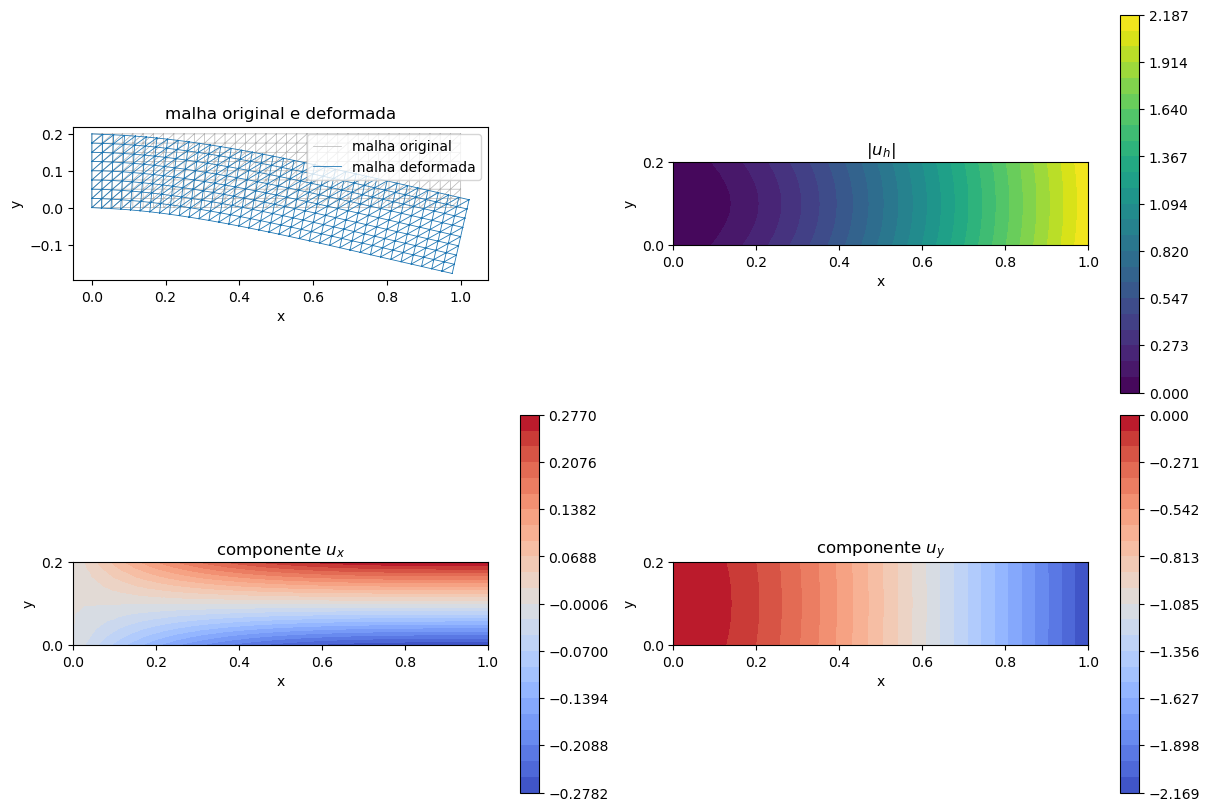

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

axes[0, 0].triplot(triangulation, color="0.7", lw=0.5, label="malha original")
axes[0, 0].triplot(
    deformed_triangulation,
    color="tab:blue",
    lw=0.6,
    label="malha deformada",
)
axes[0, 0].set_title("malha original e deformada")
axes[0, 0].legend(loc="upper right")

for ax, values, title, cmap in [
    (axes[0, 1], umag_values, r"$|u_h|$", "viridis"),
    (axes[1, 0], ux_values, r"componente $u_x$", "coolwarm"),
    (axes[1, 1], uy_values, r"componente $u_y$", "coolwarm"),
]:
    levels = make_levels(values)
    collection = ax.tricontourf(triangulation, values, levels=levels, cmap=cmap)
    fig.colorbar(collection, ax=ax)
    ax.set_title(title)

for ax in axes.flat:
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.show()

## Corte da deflexão ao longo do eixo médio

Também é útil observar como a componente vertical varia ao longo da linha
média $y = L_y/2$.

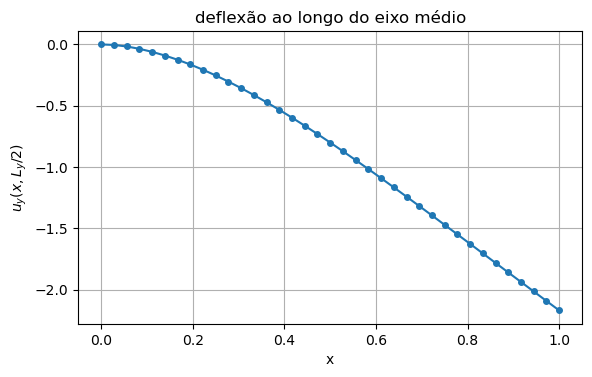

In [9]:
mask = np.isclose(coords[:, 1], Ly / 2.0)
order = np.argsort(coords[mask, 0])
x_mid = coords[mask, 0][order]
uy_mid = uy_values[mask][order]

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(x_mid, uy_mid, "o-", ms=4)
ax.set_xlabel("x")
ax.set_ylabel(r"$u_y(x, L_y/2)$")
ax.set_title("deflexão ao longo do eixo médio")
ax.grid(True)
plt.show()

## Comentário final

Neste exemplo, a principal simplificação física é o modelo constitutivo
linear. Para pequenas deformações ele é apropriado, mas não deve ser
extrapolado automaticamente para grandes rotações, plasticidade ou materiais
fortemente anisotrópicos.